<a href="https://colab.research.google.com/github/ctr/medical-physics-demos-2026-03/blob/main/MedPhys_pulseAcquireRK45.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pulse acquire using Runge-Kutta (NOT recommended)

In [4]:
# Demo 1
# Runge-Kutta 45 solution of pulse-acquire in the lab frame

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# Physical parameters
# -----------------------------
gamma = 2 * np.pi * 42.58e6      # rad/s/T (1H gyromagnetic ratio)
B0 = 0.000010                    # (convert to on resonance rotating frame with 10 uT off resonance)
T1 = 1.0                         # seconds
T2 = 0.1                         # seconds
M0 = 1.0                         # equilibrium magnetization

omega0 = gamma * B0              # Larmor frequency

# -----------------------------
# RF pulse parameters
# -----------------------------
flip_angle_deg = 90           # degrees
pulse_duration = 1e-4         # seconds, i.e. 100 microseconds

# RF amplitude required for 90-degree flip
B1 = flip_angle_deg * (np.pi / 180) / (gamma * pulse_duration)

# -----------------------------
# Bloch equations
# -----------------------------
def bloch(t, M, Bx, By, Bz):
    Mx, My, Mz = M

    dMx = gamma * (My * Bz - Mz * By) - Mx / T2
    dMy = gamma * (Mz * Bx - Mx * Bz) - My / T2
    dMz = gamma * (Mx * By - My * Bx) - (Mz - M0) / T1

    return [dMx, dMy, dMz]


In [5]:
# -----------------------------
# 1. Apply RF pulse (about x-axis)
# -----------------------------
M_init = [0, 0, M0]

sol_pulse = solve_ivp(
    lambda t, M: bloch(t, M, B1, 0, B0),
    [0, pulse_duration],
    M_init,
    method='RK45'
)

M_after_pulse = sol_pulse.y[:, -1]

print("Magnetization after RF pulse:", M_after_pulse)

Magnetization after RF pulse: [0.16916684 0.98503627 0.00644483]


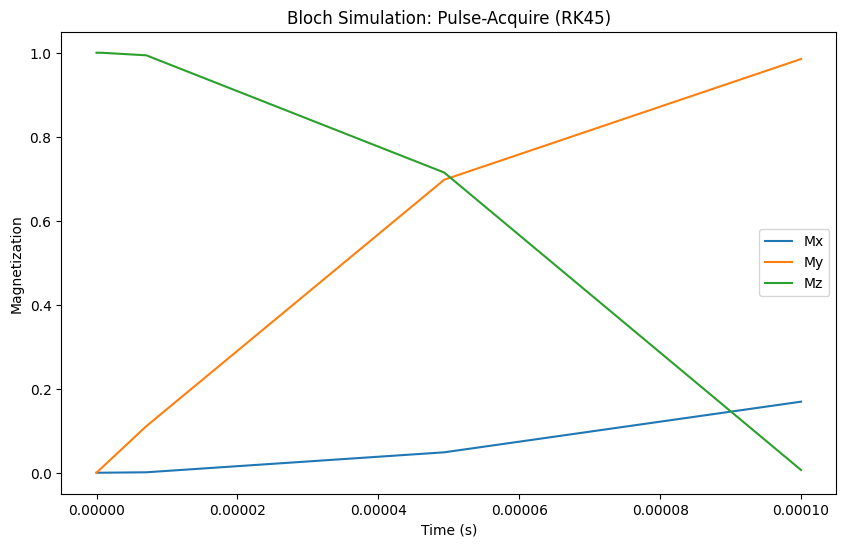

In [6]:

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(sol_pulse.t, sol_pulse.y[0,:], label="Mx")
plt.plot(sol_pulse.t, sol_pulse.y[1,:], label="My")
plt.plot(sol_pulse.t, sol_pulse.y[2,:], label="Mz")
plt.xlabel("Time (s)")
plt.ylabel("Magnetization")
plt.legend()
plt.title("Bloch Simulation: Pulse-Acquire (RK45)")
plt.show()


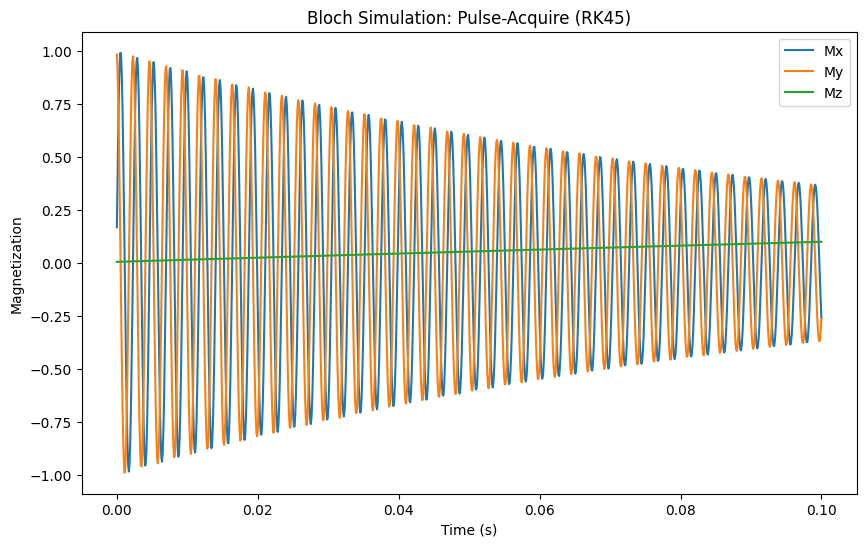

In [7]:

# -----------------------------
# 2. Free precession (FID)
# -----------------------------
acq_time = 1  # seconds

sol_acq = solve_ivp(
    lambda t, M: bloch(t, M, 0, 0, B0),
    [0, acq_time],
    M_after_pulse,
    method='RK45',
    t_eval=np.linspace(0, acq_time, 1000)
)

Mx, My, Mz = sol_acq.y
t = sol_acq.t

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(t, Mx, label="Mx")
plt.plot(t, My, label="My")
plt.plot(t, Mz, label="Mz")
plt.xlabel("Time (s)")
plt.ylabel("Magnetization")
plt.legend()
plt.title("Bloch Simulation: Pulse-Acquire (RK45)")
plt.show()
